# PPO training


device: cuda
update=0010 | ep_return=-12.576 | ep_len= 216.7 | num_ep=123 | term_ep=123 | trunc_ep=0 | partial_ret= 92.694 | partial_len= 191 | step_reward= 0.043 | |x|= 1.359 | |theta|= 1.246 | upright= 0.068 | actor_loss=-0.003 | value_loss= 140.108 | kl= 0.00488
update=0020 | ep_return= 1211.660 | ep_len= 497.4 | num_ep=47 | term_ep=28 | trunc_ep=19 | partial_ret= 825.038 | partial_len= 294 | step_reward= 2.544 | |x|= 0.590 | |theta|= 0.408 | upright= 0.651 | actor_loss=-0.002 | value_loss= 181.976 | kl= 0.00207
update=0030 | ep_return= 2554.636 | ep_len= 809.1 | num_ep=35 | term_ep=8 | trunc_ep=27 | partial_ret= 337.368 | partial_len= 139 | step_reward= 3.058 | |x|= 0.415 | |theta|= 0.284 | upright= 0.776 | actor_loss=-0.002 | value_loss= 73.855 | kl= 0.00410
update=0040 | ep_return= 2091.671 | ep_len= 660.2 | num_ep=34 | term_ep=13 | trunc_ep=21 | partial_ret= 1058.023 | partial_len= 323 | step_reward= 3.204 | |x|= 0.402 | |theta|= 0.222 | upright= 0.811 | actor_loss=-0.002 | valu

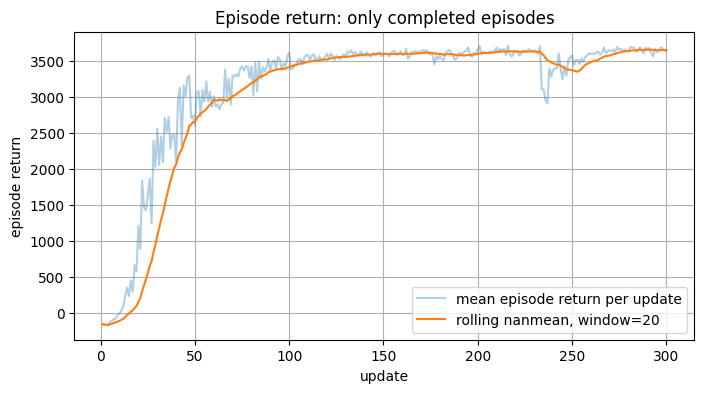

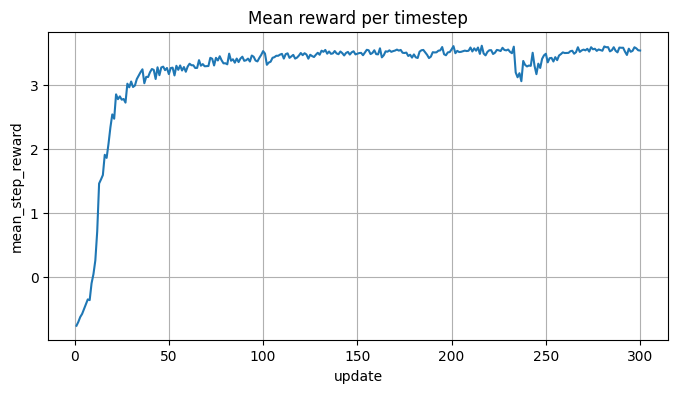

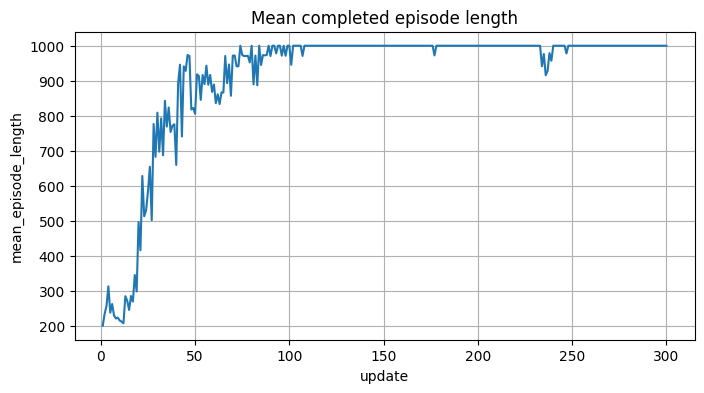

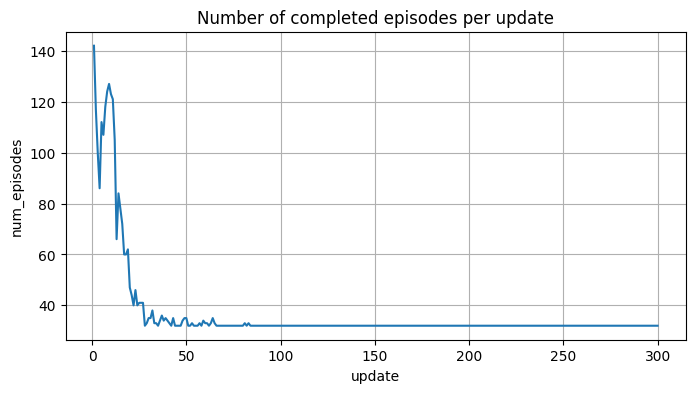

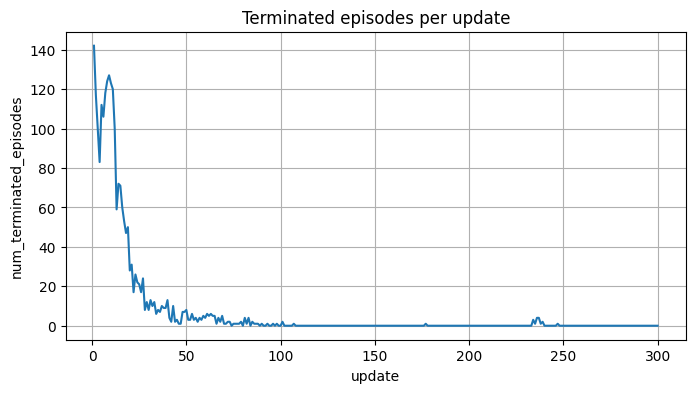

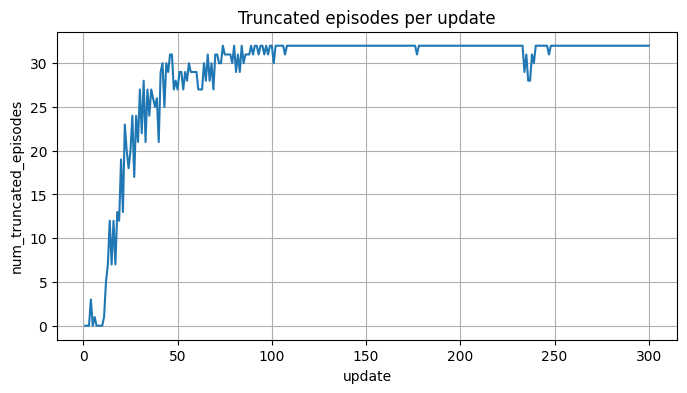

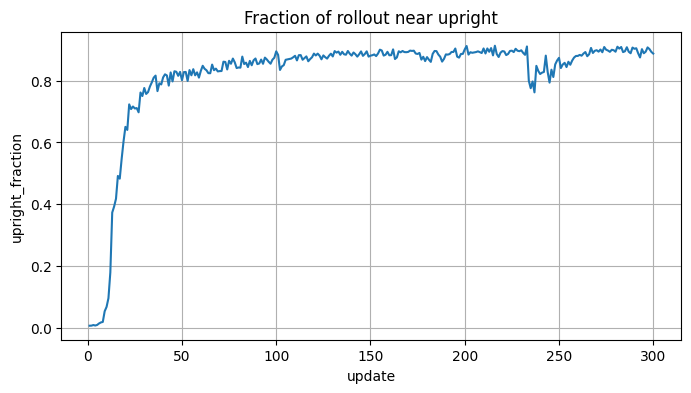

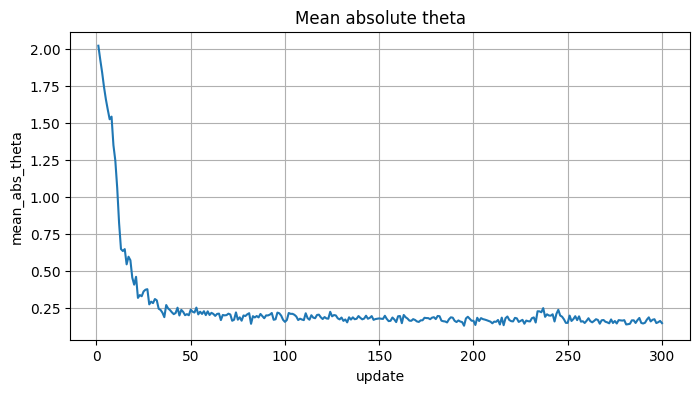

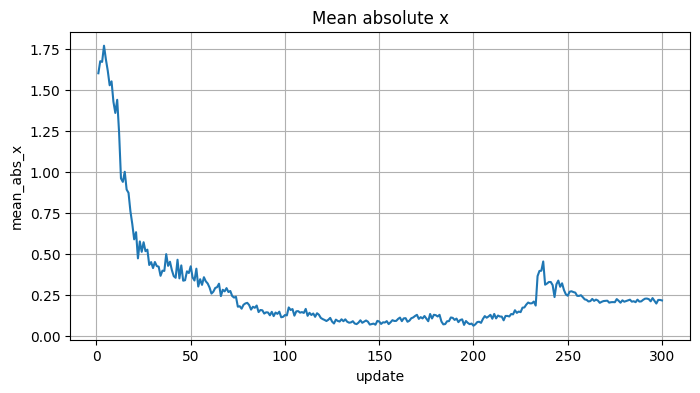

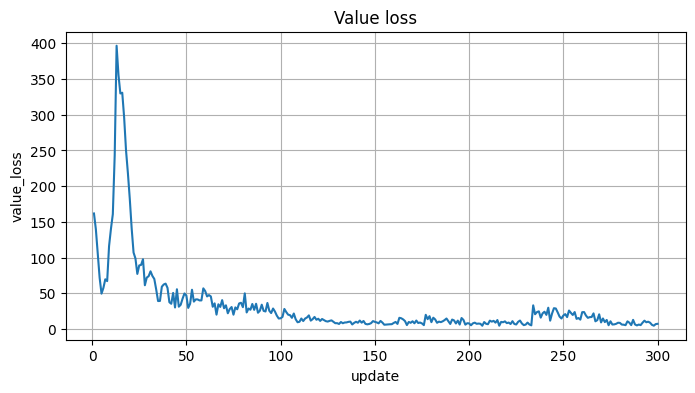

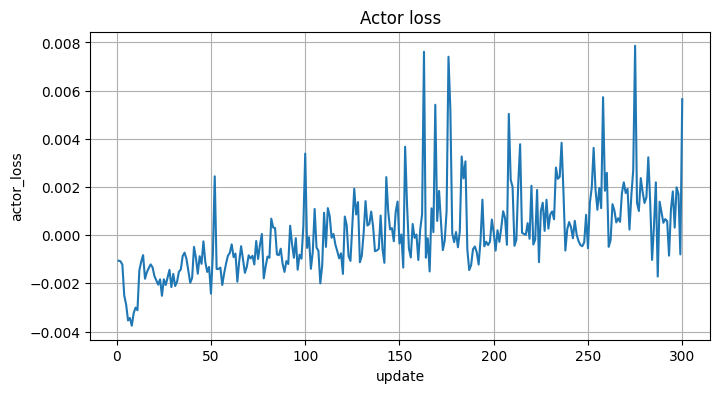

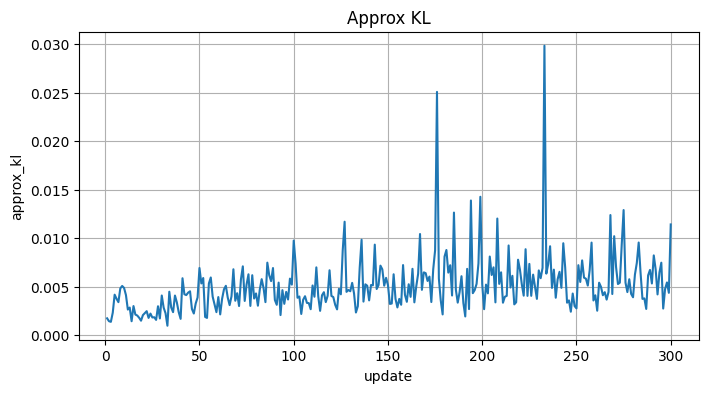

eval steps: 1000
eval return: 3605.3179791022662
terminated: False
final state [x, x_dot, theta, theta_dot]: [ 1.87576807e-01  1.04219989e-08  6.33388764e-09 -1.37839319e-08]


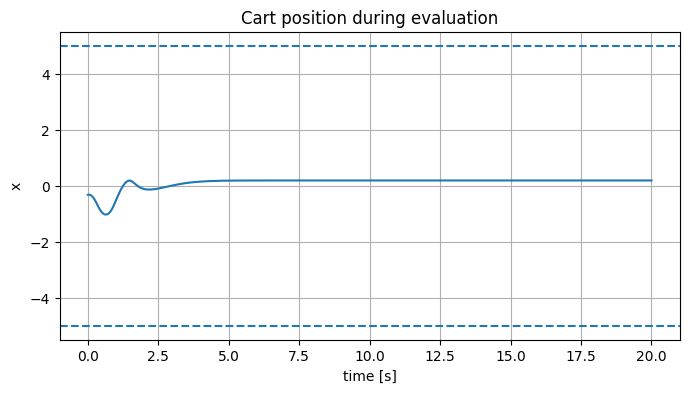

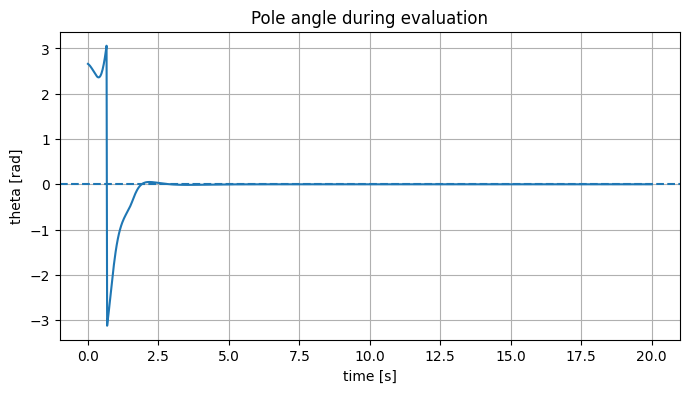

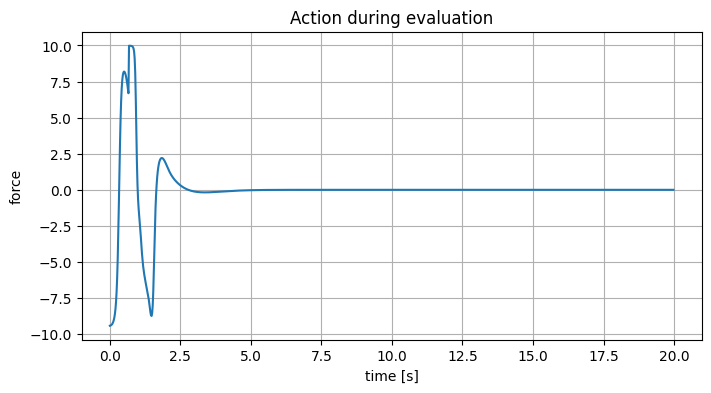

In [4]:
# Training cell for the parallel-rollout PPO implementation.

import numpy as np
import torch
import matplotlib.pyplot as plt

from cartpole import CartPole, CartPoleParams
from ppo import PPOConfig, train, run_policy

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

# Environment
params = CartPoleParams(
    cart_mass=1.0,
    pole_mass=0.1,
    pole_length=1.0,
    gravity=9.81,
    dt=0.02,
    force_limit=10.0,
    x_limit=5.0,
)

env = CartPole(params=params, seed=0)

# PPO config
cfg = PPOConfig(
    total_updates=300,

    # Runs num_rollouts independent streams in parallel.
    # total transitions per update = rollout_steps * num_rollouts.
    rollout_steps=1024,
    num_rollouts=32,

    ppo_epochs=10,
    batch_size=4096,

    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    target_kl=None,

    actor_lr=3e-4,
    critic_lr=1e-3,
    value_coef=0.5,
    entropy_coef=0.001,
    max_grad_norm=0.5,

    # Episode definition:
    # terminated if |x| > x_limit
    # truncated if episode length reaches max_episode_steps
    x_limit=params.x_limit,
    max_episode_steps=1000,

    # Random reset for swing-up from arbitrary angle.
    random_reset=True,
    reset_x_range=0.5,
    reset_x_dot_range=0.5,
    reset_theta_range=np.pi,
    reset_theta_dot_range=1.0,

    # Reward shaping.
    x_penalty=0.03,
    x_dot_penalty=0.005,
    theta_dot_penalty=0.01,
    action_penalty=0.001,
    done_penalty=20.0,
    upright_bonus=3.0,

    upright_theta_threshold=0.15,
    upright_theta_dot_threshold=0.5,
    upright_x_threshold=0.5,

    seed=0,
    device=DEVICE,
    print_every=10,
    checkpoint_dir="checkpoints_rollouts_4",
    checkpoint_prefix="ppo_cartpole",
)

agent, history = train(env, cfg)

# ---------- Plot helpers ----------

def plot_history(key, title=None):
    y = np.asarray(history[key], dtype=float)
    x = np.asarray(history["update"], dtype=int)

    plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.xlabel("update")
    plt.ylabel(key)
    plt.title(title or key)
    plt.grid(True)
    plt.show()


def rolling_nanmean(values, window=20):
    values = np.asarray(values, dtype=float)
    out = np.full_like(values, np.nan, dtype=float)
    for i in range(len(values)):
        start = max(0, i - window + 1)
        chunk = values[start : i + 1]
        if np.isfinite(chunk).any():
            out[i] = np.nanmean(chunk)
    return out


def plot_episode_return(window=20):
    y = np.asarray(history["mean_episode_return"], dtype=float)
    x = np.asarray(history["update"], dtype=int)
    y_smooth = rolling_nanmean(y, window=window)

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, alpha=0.35, label="mean episode return per update")
    plt.plot(x, y_smooth, label=f"rolling nanmean, window={window}")
    plt.xlabel("update")
    plt.ylabel("episode return")
    plt.title("Episode return: only completed episodes")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_episode_return(window=20)
plot_history("mean_step_reward", "Mean reward per timestep")
plot_history("mean_episode_length", "Mean completed episode length")
plot_history("num_episodes", "Number of completed episodes per update")
plot_history("num_terminated_episodes", "Terminated episodes per update")
plot_history("num_truncated_episodes", "Truncated episodes per update")
plot_history("upright_fraction", "Fraction of rollout near upright")
plot_history("mean_abs_theta", "Mean absolute theta")
plot_history("mean_abs_x", "Mean absolute x")
plot_history("value_loss", "Value loss")
plot_history("actor_loss", "Actor loss")
plot_history("approx_kl", "Approx KL")

# ---------- Evaluate trained policy ----------

# Evaluate from a random swing-up initial state sampled using the same reset distribution.
eval_env = CartPole(params=params, seed=123)
states, actions, rewards = run_policy(
    eval_env,
    agent,
    max_steps=cfg.max_episode_steps,
    x_limit=cfg.x_limit,
    device=cfg.device,
    deterministic=True,
    cfg=cfg,
    use_random_reset=True,
)

print("eval steps:", len(rewards))
print("eval return:", float(np.sum(rewards)))
print("terminated:", abs(float(states[-1, 0])) > cfg.x_limit)
print("final state [x, x_dot, theta, theta_dot]:", states[-1])

# Plot evaluation trajectory.
t = np.arange(states.shape[0]) * params.dt

plt.figure(figsize=(8, 4))
plt.plot(t, states[:, 0])
plt.axhline(cfg.x_limit, linestyle="--")
plt.axhline(-cfg.x_limit, linestyle="--")
plt.xlabel("time [s]")
plt.ylabel("x")
plt.title("Cart position during evaluation")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, states[:, 2])
plt.axhline(0.0, linestyle="--")
plt.xlabel("time [s]")
plt.ylabel("theta [rad]")
plt.title("Pole angle during evaluation")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(actions)) * params.dt, actions.reshape(-1))
plt.xlabel("time [s]")
plt.ylabel("force")
plt.title("Action during evaluation")
plt.grid(True)
plt.show()


In [ ]:
# ---------- Visualize best checkpoint policy ----------

from pathlib import Path
import sys

import numpy as np
import torch
from IPython.display import HTML, display

# Make imports work whether the notebook kernel starts in week4/ or repo root.
if not Path("ppo.py").exists() and Path("week4/ppo.py").exists():
    sys.path.insert(0, str(Path("week4").resolve()))

from cartpole import CartPole, CartPoleParams
from ppo import Agent, PPOConfig, run_policy
from simulation import create_cartpole_animation

checkpoint_candidates = [
    Path("checkpoints/ppo_cartpole_best.pt"),
    Path("week4/checkpoints/ppo_cartpole_best.pt"),
]
checkpoint_path = next((path for path in checkpoint_candidates if path.exists()), None)
if checkpoint_path is None:
    raise FileNotFoundError("Could not find ppo_cartpole_best.pt in checkpoints/ or week4/checkpoints/.")

device = "cuda" if torch.cuda.is_available() else "cpu"
try:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=device)

cfg_best = PPOConfig(**checkpoint["config"])
cfg_best.device = device

# Reuse the training CartPoleParams if this cell is run after the training cell.
sim_params = globals().get(
    "params",
    CartPoleParams(dt=0.02, force_limit=10.0, x_limit=cfg_best.x_limit),
)

model_env = CartPole(params=sim_params, seed=0)
best_agent = Agent(model_env).to(device)
best_agent.load_state_dict(checkpoint["agent_state_dict"])
best_agent.eval()

# Start near the downward position to make swing-up behavior visible.
# Change this vector to try other initial states: [x, x_dot, theta, theta_dot].
state0 = np.array([0.0, 0.0, 2.5, 0.0], dtype=float)
max_steps = 5000

sim_env = CartPole(params=sim_params, seed=123)
states_best, actions_best, rewards_best = run_policy(
    sim_env,
    best_agent,
    max_steps=max_steps,
    x_limit=cfg_best.x_limit,
    device=device,
    deterministic=True,
    state0=state0,
    cfg=cfg_best,
)

print(f"loaded checkpoint: {checkpoint_path}")
print(f"checkpoint update: {checkpoint.get('update')}")
print(f"best checkpoint return: {checkpoint.get('best_ep_return')}")
print(f"simulation steps: {len(rewards_best)}")
print(f"simulation return: {float(np.sum(rewards_best)):.3f}")
print("terminated:", abs(float(states_best[-1, 0])) > cfg_best.x_limit)
print("final state [x, x_dot, theta, theta_dot]:", states_best[-1])

anim = create_cartpole_animation(states_best, sim_params, frame_stride=2)
display(HTML(anim.to_jshtml()))


# REPPO training

device: cuda
update=0010 | ep_return=-71.369 | ep_len= 1000.0 | num_ep=16 | term_ep=0 | trunc_ep=16 | partial_ret= 0.000 | partial_len= 0 | step_reward=-0.071 | |x|= 1.290 | |theta|= 1.297 | upright= 0.006 | actor_loss=-91.431 | q_loss= 2.184 | kl= 0.02276 | H= 1.593 | alpha= 0.00100 | beta= 0.98655
update=0020 | ep_return= 3383.979 | ep_len= 1000.0 | num_ep=16 | term_ep=0 | trunc_ep=16 | partial_ret= 0.000 | partial_len= 0 | step_reward= 3.384 | |x|= 0.263 | |theta|= 0.188 | upright= 0.863 | actor_loss=-138.603 | q_loss= 2.135 | kl= 0.02660 | H= 1.493 | alpha= 0.00099 | beta= 0.96462
update=0030 | ep_return= 3429.190 | ep_len= 1000.0 | num_ep=16 | term_ep=0 | trunc_ep=16 | partial_ret= 0.000 | partial_len= 0 | step_reward= 3.429 | |x|= 0.208 | |theta|= 0.179 | upright= 0.876 | actor_loss=-175.625 | q_loss= 2.132 | kl= 0.02320 | H= 1.374 | alpha= 0.00099 | beta= 0.93334
update=0040 | ep_return= 1869.055 | ep_len= 1000.0 | num_ep=16 | term_ep=0 | trunc_ep=16 | partial_ret= 0.000 | parti

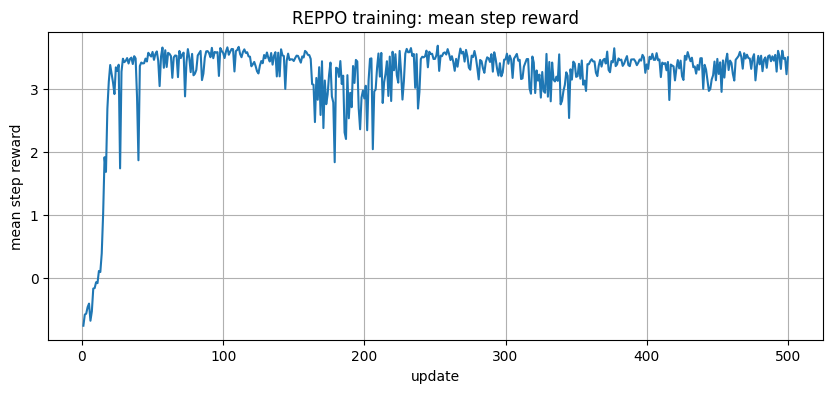

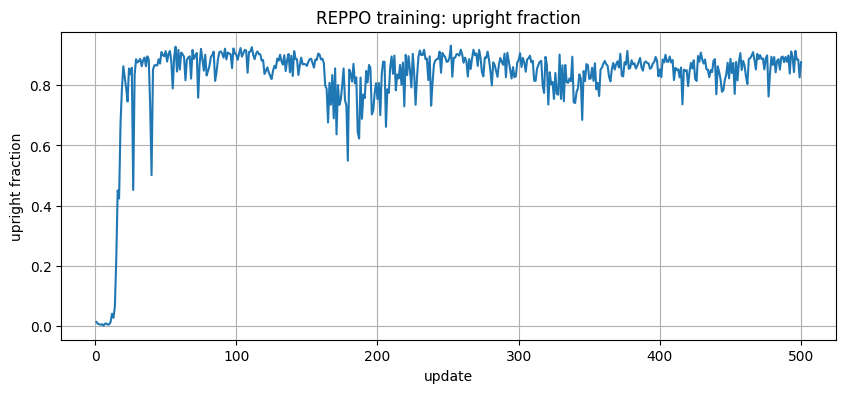

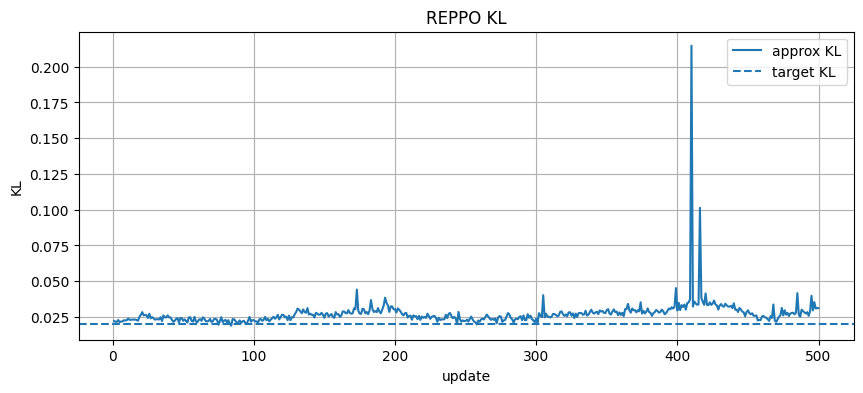

In [3]:
# ===== Train REPPO CartPole =====
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from reppo import REPPOConfig, CartPole, train, run_policy

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
if device == "cuda":
    torch.cuda.manual_seed_all(seed)

cfg = REPPOConfig(
    total_updates=500,
    rollout_steps=2000,
    num_rollouts=8,
    ppo_epochs=10,
    batch_size=256,

    gamma=0.99,
    gae_lambda=0.95,

    actor_lr=3e-4,
    critic_lr=1e-3,
    max_grad_norm=0.5,

    target_kl=0.02,
    target_entropy=1.0,
    initial_alpha=1e-3,
    initial_beta=1.0,
    alpha_lr=1e-3,
    beta_lr=1e-3,

    max_episode_steps=1000,
    random_reset=True,

    seed=seed,
    device=device,
    print_every=10,
    checkpoint_dir="checkpoints_reppo",
    checkpoint_prefix="reppo_cartpole",
)

# Quan trọng: code REPPO hiện tại đặt default q range = [1000, 4000],
# không hợp với discounted Q của reward CartPole này.
# Với reward tối đa khoảng 4/step và gamma=0.99, Q max lý thuyết xấp xỉ 400.
cfg.q_bin = 10
cfg.target_q_std = 2.0 * cfg.q_bin
cfg.q_value_min = -500.0
cfg.q_value_max = 3000
cfg.num_q_bins = int((cfg.q_value_max - cfg.q_value_min) // cfg.q_bin + 1)

env = CartPole(seed=cfg.seed)

agent, history = train(env, cfg)

# ===== Quick deterministic evaluation =====
eval_env = CartPole(seed=cfg.seed + 123)
states, actions, rewards = run_policy(
    eval_env,
    agent,
    max_steps=1000,
    x_limit=cfg.x_limit,
    device=cfg.device,
    deterministic=True,
    cfg=cfg,
    use_random_reset=True,
)

print("\nEvaluation:")
print("return:", float(np.sum(rewards)))
print("length:", len(rewards))
print("mean |x|:", float(np.mean(np.abs(states[:, 0]))))
print("mean |theta|:", float(np.mean(np.abs(states[:, 2]))))

# ===== Plot training curves =====
updates = np.asarray(history["update"])

plt.figure(figsize=(10, 4))
plt.plot(updates, history["mean_step_reward"])
plt.xlabel("update")
plt.ylabel("mean step reward")
plt.title("REPPO training: mean step reward")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(updates, history["upright_fraction"])
plt.xlabel("update")
plt.ylabel("upright fraction")
plt.title("REPPO training: upright fraction")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(updates, history["approx_kl"], label="approx KL")
plt.axhline(cfg.target_kl, linestyle="--", label="target KL")
plt.xlabel("update")
plt.ylabel("KL")
plt.title("REPPO KL")
plt.legend()
plt.grid(True)
plt.show()